# 2b Polyketides EIC data analysis

## Load libraries

In [1]:
library(RColorBrewer)
library(dplyr)
library(ggplot2)
library(readxl)
library(patchwork)
library(ggtext)
library(tidyverse)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.1
✔ readr     2.1.5     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


## Load and combine EIC data and metadata

In [ ]:
# Set working directory
wd <- "/path/to/04_bioassays"

# Load combined EIC data (exported from Python)
df <- read_csv(paste0(wd, "/03_data/tables/samplelist.xlsx"))

# Convert retention time from seconds to minutes
df <- df %>%
  mutate(RT_min = RT / 60)

# Load sample metadata
md_path <- paste0(wd, "/03_data/tables/samplelist.xlsx")
md.load <- read_excel(md_path)
md <- md.load

# Generate file names to match EIC data
md$File <- paste0(sprintf("%02d_", md$Number), md$Name, ".mzML")

# Join metadata to EIC data
df <- df %>% left_join(., md, by = "File")

## Define colors and parameters

In [96]:
# Define color palette for each strain
wt_colors <- brewer.pal(n = 9, name = "Greens")
disfp_colors <- brewer.pal(n = 9, name = "Purples")
rescue_colors <- brewer.pal(n = 9, name = "Blues")

color_nr <- 6
strain_colors <- c(
  "wt" = wt_colors[color_nr],
  "ko" = disfp_colors[color_nr],
  "re" = rescue_colors[color_nr],
  "standard" = "brown"
)

# Initialize an empty list to collect plots
plot_list <- list()

# Separate samples and blanks
df_blank <- df %>% filter(strain == "blank")
df_samples <- df %>% filter(strain != "blank")

# Labels for legend
strain_rename <- c(
  "ko" = bquote(italic(disfp)^"–" ~ "mutant"),
  "wt" = bquote("Ax2 wildtype"),
  "re" = bquote(italic(disfp)^"–" ~ "rescue")
)

# Define EIC targets and expected retention time windows
metabs <- list(
  "DIF-1"      = list(mode = "neg", xlim = c(7.0, 7.5)),
  "PCP"        = list(mode = "neg", xlim = c(5.4, 5.7)),
  "MPBD"       = list(mode = "pos", xlim = c(5.73, 5.78)),
  "Dictyodene" = list(mode = "neg", xlim = c(5.6, 6.4))
)

# Determine label for last target (used for conditional legend display)
last_target <- tail(names(metabs), 1)

## Plot the EICs

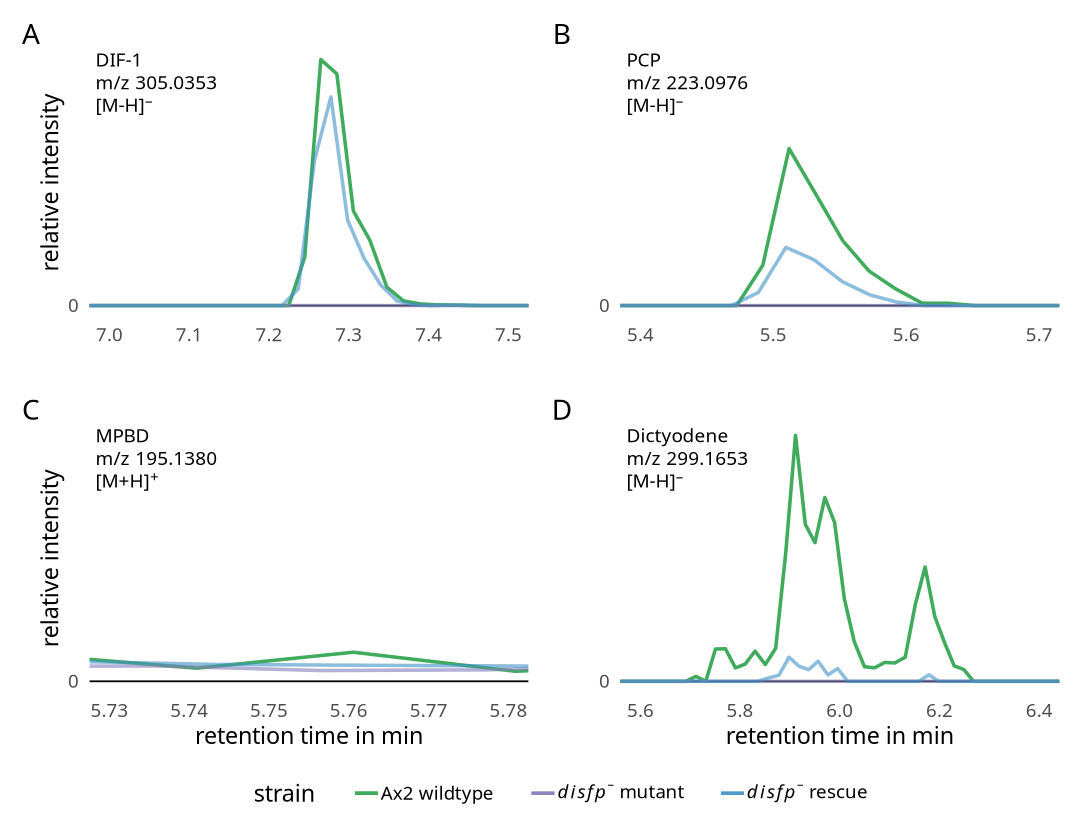

In [ ]:
# Generate and collect EIC plots for each selected polyketide
plot_list <- list()
last_target <- tail(names(metabs), 1)

for (target in names(metabs)) {
  # Extract settings for current metabolite
  mode_selected <- metabs[[target]]$mode
  xlims         <- metabs[[target]]$xlim

  # Filter data by feature, mode, and exclude controls
  df_filtered <- df %>%
    filter(feature == target, mode == mode_selected, group != "ctrl")

  # Extract unique m/z value
  mz_value <- df_filtered %>% pull(mz) %>% unique()
  mz_value <- if (length(mz_value) == 0) "NA" else sprintf("%.4f", mz_value[1])

  # Create label string for richtext annotation
  my_label <- if (mode_selected == "pos") {
    paste0(
      target, "<br>",
      "<span style='word-spacing:6px;'>m/z </span> ", mz_value, "<br>",
      "[M+H] <sup>+</sup>"
    )
  } else {
    paste0(
      target, "<br>",
      "<span style='word-spacing:6px;'>m/z </span> ", mz_value, "<br>",
      "[M-H]<sup>–</sup>"
    )
  }

  # Separate blanks and samples
  df_blank   <- df_filtered %>% filter(strain == "blank")
  df_samples <- df_filtered %>% filter(strain != "blank")

  # Subtract interpolated blank intensity if enough blank points are available
  if (nrow(df_blank) < 2) {
    df_corrected <- df_samples %>%
      mutate(
        blank_intensity = NA_real_,
        corrected_intensity = Intensity
      )
  } else {
    df_corrected <- df_samples %>%
      group_by(File, group) %>%
      mutate(
        blank_intensity = approx(x = df_blank$RT_min,
                                 y = df_blank$Intensity,
                                 xout = RT_min,
                                 rule = 2)$y,
        corrected_intensity = pmax(Intensity - blank_intensity, 0)
      ) %>%
      ungroup()
  }



  # Set factor levels for consistent ordering
  df_corrected <- df_corrected %>%
    mutate(
      strain = factor(strain, levels = c("ko", "wt", "re", "blank", "standard")),
      group  = factor(group, levels = c("sample", "ctrl"))
    )

  # Filter for RT interval
  df_samples_RT <- df_corrected %>%
    filter(between(RT, xlims[1]*60, xlims[2]*60))

  # Axis labeling logic
  i <- which(names(metabs) == target)
  xlab <- if (i %in% c(3, 4)) "retention time in min" else ""
  ylab <- if (i %in% c(1, 3)) "relative intensity" else ""

  # Determine annotation offsets
  offset_x <- diff(xlims) * 0.02
  max_y <- if (nrow(df_samples_RT) > 0) max(df_samples_RT$corrected_intensity, na.rm = TRUE) else 1
  offset_y <- max_y * 0.02

  # Plot lines in specific order (wt, ko, standard)
  p <- ggplot() +
    geom_hline(yintercept = 0, linetype = "solid", color = "black") +
    geom_line(
      data = df_corrected %>% filter(strain == "wt", Name == "Ax2"),
      aes(x = RT_min, y = corrected_intensity, color = strain, group = File),
      size = 1
    ) +
    geom_line(
      data = df_corrected %>% filter(strain == "ko", Name == "DiSfp3"),
      aes(x = RT_min, y = corrected_intensity, color = strain, group = File),
      size = 1, alpha = 0.6
    ) +
    geom_line(
      data = df_corrected %>% filter(strain == "re", Name == "DiSfp3_rescue"),
      aes(x = RT_min, y = corrected_intensity, color = strain, group = File),
      size = 1, alpha = 0.6
    ) +
    geom_line(
      data = df_corrected %>% filter(strain == "standard"),
      aes(x = RT_min, y = corrected_intensity, color = strain, group = File),
      size = 1, alpha = 0.8
    ) +
    scale_y_continuous(breaks = c(0)) +
    scale_color_manual(values = strain_colors, labels = strain_rename) +
    coord_cartesian(xlim = xlims) + 
    theme_minimal(base_size = 14) +
    theme(
      panel.grid = element_blank(),
      legend.position = if (target == last_target) c(0.95, 1.025) else "none",
      legend.justification = if (target == last_target) c("right", "top") else NULL
    ) +
    labs(x = xlab, y = ylab) +
    annotate(
      "richtext",
      x = -Inf, y = Inf,
      label = my_label,
      hjust = 0, vjust = 1,
      fill = NA, label.color = NA,
      size = 4
    )

  plot_list[[target]] <- p
}

# Combine all plots into a single panel layout
options(repr.plot.width = 9, repr.plot.height = 7)

combined_plot <- wrap_plots(plot_list, ncol = 2, guides = "collect") +
  plot_layout(guides = "collect") +
  plot_annotation(tag_levels = "A") &
  theme(
    legend.position = "bottom",
    legend.text = element_text(margin = margin(r = 20, unit = "pt")),
    legend.title = element_text(margin = margin(r = 25, unit = "pt"))
  )

combined_plot
